<a href="https://colab.research.google.com/github/edwardsnj/glygen-colab-notebooks/blob/main/uniprotkb_nlinked_sites/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#
# Import the modules from the github repository
#
import httpimport

with httpimport.github_repo("edwardsnj","glygen-colab-notebooks", ref="main"):
  from glygen import GlyGenDownloader


In [2]:
# Download UniProtKB protein site annotations for each species
ggdl = GlyGenDownloader()

template = "*_protein_site_annotation_uniprotkb.csv"
FILES = ggdl.filenames(template)

params = {
  "usecols": ["uniprotkb_canonical_ac","start_pos","ref_aa","ann_type","annotation","xref_key","xref_id"],
  "notna": ["start_pos","xref_id"],
  "asint": ["start_pos"],
  "addfilename": True,
  "transform": {"species": lambda df: (df['filename'].str.split("_", expand=True))[0]},
  "dropcols": ["filename"],
  "dropdups": True,
}
uniprotkb_site_annotations = ggdl.dataframe(FILES,**params)


Download arabidopsis_protein_site_annotation_uniprotkb.csv... done (5.93 MB).
Download bovine_protein_site_annotation_uniprotkb.csv... done (3.91 MB).
Download chicken_protein_site_annotation_uniprotkb.csv... done (1.40 MB).
Download dicty_protein_site_annotation_uniprotkb.csv... done (672.98 KB).
Download fruitfly_protein_site_annotation_uniprotkb.csv... done (3.04 MB).
Download hamster_protein_site_annotation_uniprotkb.csv... done (752.29 KB).
Download hcv1a_protein_site_annotation_uniprotkb.csv... done (31.71 KB).
Download hcv1b_protein_site_annotation_uniprotkb.csv... done (31.34 KB).
Download human_protein_site_annotation_uniprotkb.csv... done (53.79 MB).
Download mouse_protein_site_annotation_uniprotkb.csv... done (15.80 MB).
Download pig_protein_site_annotation_uniprotkb.csv... done (1.70 MB).
Download rat_protein_site_annotation_uniprotkb.csv... done (7.69 MB).
Download sarscov1_protein_site_annotation_uniprotkb.csv... done (68.27 KB).
Download sarscov2_protein_site_annotation_

In [8]:
# Select N-linked GlcNAc Asn sites with PubMed ids

# Select the desired degree of specificity
# nlinked_rows = uniprotkb_site_annotations["annotation"].str.contains("N-linked")
nlinked_rows = uniprotkb_site_annotations["annotation"] == "N-linked (GlcNAc...) asparagine"

pubmed_rows = uniprotkb_site_annotations["xref_key"]=="protein_xref_pubmed"

# Likey not needed
asn_rows = uniprotkb_site_annotations['ref_aa']=="N"

nlinked_sites_pubmed = uniprotkb_site_annotations[nlinked_rows&pubmed_rows&asn_rows]
nlinked_sites_pubmed.rename({"xref_id": "pubmed_id"}, inplace=True)
nlinked_sites_pubmed.drop(columns=["xref_key"], inplace=True)
nlinked_sites_pubmed

,uniprotkb_canonical_ac,ann_type,start_pos,annotation,ref_aa,xref_key,xref_id,species
1912,O64743-1,Glycosylation_Annotation,431,N-linked (GlcNAc...) asparagine,N,protein_xref_pubmed,26037923,arabidopsis
1915,O64743-1,Glycosylation_Annotation,57,N-linked (GlcNAc...) asparagine,N,protein_xref_pubmed,26037923,arabidopsis
2813,P24806-1,Glycosylation_Annotation,106,N-linked (GlcNAc...) asparagine,N,protein_xref_pubmed,10406121,arabidopsis
4868,Q9FL28-1,Glycosylation_Annotation,94,N-linked (GlcNAc...) asparagine,N,protein_xref_pubmed,24114786,arabidopsis
4870,Q9FL28-1,Glycosylation_Annotation,388,N-linked (GlcNAc...) asparagine,N,protein_xref_pubmed,24114786,arabidopsis
...,...,...,...,...,...,...,...,...
626731,F8W463-1,Glycosylation_Annotation,113,N-linked (GlcNAc...) asparagine,N,protein_xref_pubmed,22535247,zebrafish
626732,F8W463-1,Glycosylation_Annotation,113,N-linked (GlcNAc...) asparagine,N,protein_xref_pubmed,19641588,zebrafish
626734,F8W463-1,Glycosylation_Annotation,187,N-linked (GlcNAc...) asparagine,N,protein_xref_pubmed,19641588,zebrafish
626736,F8W463-1,Glycosylation_Annotation,213,N-linked (GlcNAc...) asparagine,N,protein_xref_pubmed,19641588,zebrafish


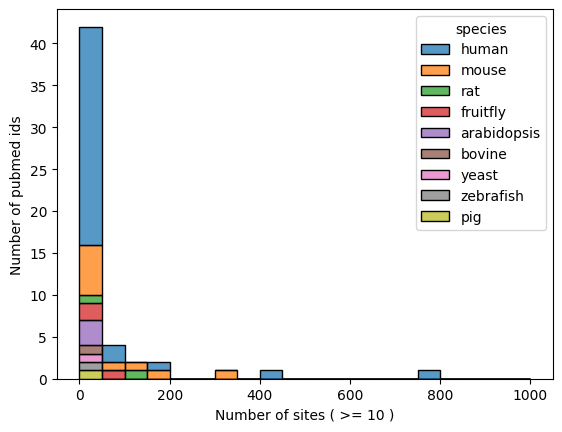

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Plot histogram of frequency of sites in a pubmed id (partition by species)
counts = pd.DataFrame(nlinked_sites_pubmed[["xref_id","species"]].value_counts())
counts.reset_index("species", inplace=True)
counts = counts[counts["count"] >= 10]

sns.histplot(data=counts, x='count', hue="species",
             binwidth=50, binrange=(0,1000), multiple="stack")
plt.xlabel("Number of sites ( >= 10 )")
plt.ylabel("Number of pubmed ids")
plt.show()

# Interactive

fig = px.histogram(counts, x="count", color="species")
fig.layout.xaxis.title = "Number of sites ( >= 10 )"
fig.layout.yaxis.title = "Number of pubmed ids"
fig.update_layout(bargap=0.1)
fig.update_traces(xbins=dict(start=0, end=1000, size=50))
fig.show()

In [7]:
counts[counts["count"]>=100]

,species,count
xref_id,,
19159218,human,788
16335952,human,424
19349973,mouse,329
19656770,mouse,178
19349973,human,167
24090084,rat,126
16944957,mouse,110
